In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,classification_report
from sklearn.preprocessing import StandardScaler


In [3]:
df =sns.load_dataset("titanic")

In [4]:
df.head()
df = df.drop("alive", axis=1)

In [5]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alone            0
dtype: int64

In [6]:
df = df.drop("who", axis=1)
df = df.drop("deck", axis=1)

In [7]:
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
df[["age"]] = imp_median.fit_transform(df[["age"]])


In [9]:
from sklearn.preprocessing import LabelEncoder

lable_enc = LabelEncoder()
df["sex"] = lable_enc.fit_transform(df["sex"])
df["embarked"] = lable_enc.fit_transform(df["embarked"])
df["class"] = lable_enc.fit_transform(df["class"])
df["alone"] = lable_enc.fit_transform(df["alone"])
df["adult_male"] = lable_enc.fit_transform(df["adult_male"])
df["class"] = lable_enc.fit_transform(df["class"])
df["embark_town"] = lable_enc.fit_transform(df["embark_town"])


In [10]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,2,0
1,1,1,0,38.0,1,0,71.2833,0,0,0,0,0
2,1,3,0,26.0,0,0,7.9250,2,2,0,2,1
3,1,1,0,35.0,1,0,53.1000,2,0,0,2,0
4,0,3,1,35.0,0,0,8.0500,2,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,2,1,1,2,1
887,1,1,0,19.0,0,0,30.0000,2,0,0,2,1
888,0,3,0,28.0,1,2,23.4500,2,2,0,2,0
889,1,1,1,26.0,0,0,30.0000,0,0,1,0,1


In [11]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,2,0
1,1,1,0,38.0,1,0,71.2833,0,0,0,0,0
2,1,3,0,26.0,0,0,7.9250,2,2,0,2,1
3,1,1,0,35.0,1,0,53.1000,2,0,0,2,0
4,0,3,1,35.0,0,0,8.0500,2,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,2,1,1,2,1
887,1,1,0,19.0,0,0,30.0000,2,0,0,2,1
888,0,3,0,28.0,1,2,23.4500,2,2,0,2,0
889,1,1,1,26.0,0,0,30.0000,0,0,1,0,1


In [12]:
x = df.drop("survived",axis=1)
y = df["survived"]

In [13]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,random_state=42
)

In [14]:
x_train

,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town,alone
298,1,1,28.00,0,0,30.5000,2,0,1,2,1
884,3,1,25.00,0,0,7.0500,2,2,1,2,1
247,2,0,24.00,0,2,14.5000,2,1,0,2,0
478,3,1,22.00,0,0,7.5208,2,2,1,2,1
305,1,1,0.92,1,2,151.5500,2,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...
106,3,0,21.00,0,0,7.6500,2,2,0,2,1
270,1,1,28.00,0,0,31.0000,2,0,1,2,1
860,3,1,41.00,2,0,14.1083,2,2,1,2,0
435,1,0,14.00,1,2,120.0000,2,0,0,2,0


In [26]:
from sklearn.metrics import accuracy_score,r2_score
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3)

model.fit(x_train, y_train)

y_pred_test = model.predict(x_test)
y_pred_train = model.predict(x_train)

print("Training accuracy: ", accuracy_score(y_train, y_pred_train))
print("Testing accuracy: ", accuracy_score(y_test, y_pred_test ))
# classic case of overfitting

Training accuracy:  0.8368263473053892
Testing accuracy:  0.8251121076233184


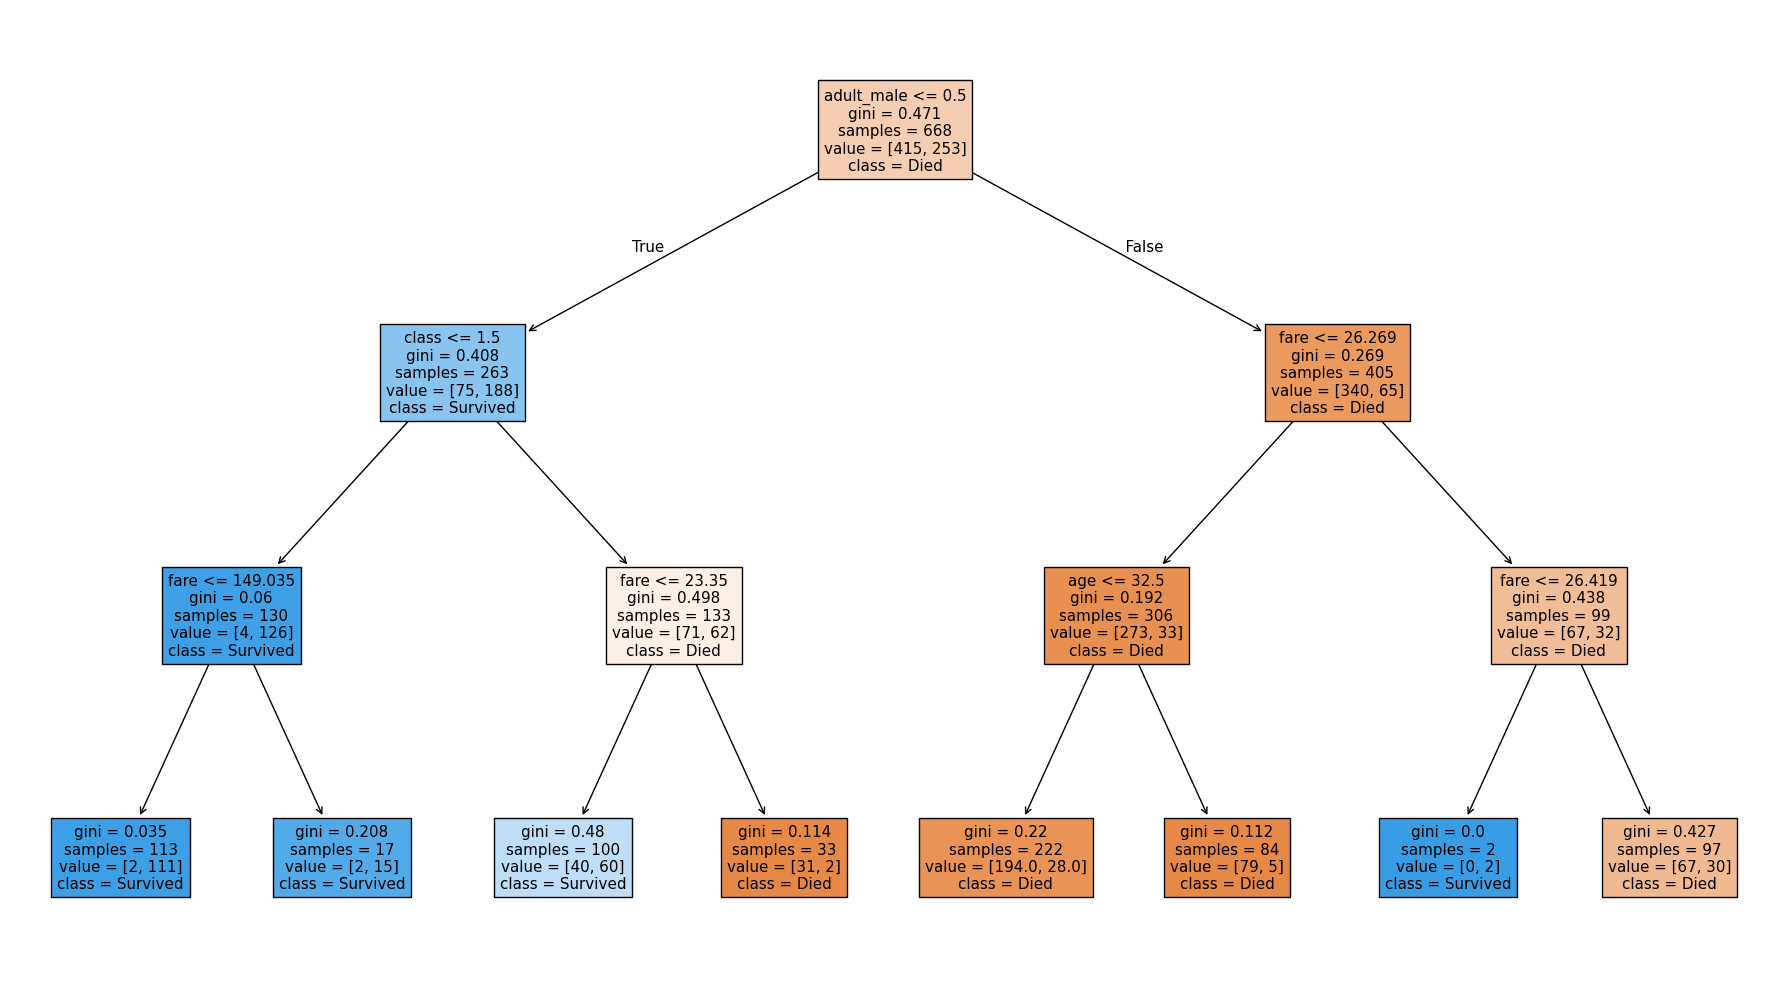

In [27]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=["Died", "Survived"],
    filled=True
)

plt.tight_layout()

In [44]:
from sklearn.ensemble import RandomForestClassifier 
ref = RandomForestClassifier(
    n_estimators=501,
    oob_score=True,
    max_depth=3
)

ref.fit(x_train,y_train)
y_pref = ref.predict(x_test)

print("score : ", ref.oob_score_* 100,"%")
print("testing accuracy: ", accuracy_score(y_test, y_pref) * 100,"%")

score :  81.88622754491018 %
testing accuracy:  81.61434977578476 %
